In [7]:
import numpy as np
import csv
from sklearn.decomposition import PCA

In [8]:
filename = 'compTempR.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(',')[:-1])
for x in dense_coding_table[:10]:
    print(x)

['verse', 'eng', 'cym', 'deu']
['40001011', 'at', 'yn', 'zu']
['40005021', 'in', 'wrth', 'zu']
['40009022', 'at', 'o', '--']
['40010019', 'at', 'yn', 'in']
['40012005', 'on', 'ar', 'an']
['40012010', 'on', 'ar', 'an']
['40012011', 'on', 'ar', 'an']
['40012012', 'on', 'ar', 'an']
['40013040', 'at', 'yn', 'an']


In [9]:
def get_dense_coding(filename = 'compTempR.csv'):
    dense_coding_table = []
    for line in open(filename):
        dense_coding_table.append(line.strip('\n').split(','))
    return dense_coding_table


def get_sparse_coding(dense_coding_table, no_response = '--'):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
 #       if language == 'eng': continue
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
#            if language == 'eng': continue
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng': {'at': 0, 'in': 1, 'on': 2}, 'cym': {'yn': 0, 'wrth': 1, 'o': 2, 'ar': 3, 'zero': 4, 'pryd': 5, 'ymhen': 6, 'mewn': 7, 'tridiau': 8, 'am': 9, 'tua': 10}, 'deu': {'zu': 0, 'in': 1, 'an': 2, 'zero': 3, 'nach': 4, 'um': 5, '_an': 6, 'bei': 7, 'von': 8, '_nach': 9}}
>>> header ['eng_at', 'eng_in', 'eng_on', 'cym_yn', 'cym_wrth', 'cym_o', 'cym_ar', 'cym_zero', 'cym_pryd', 'cym_ymhen', 'cym_mewn', 'cym_tridiau', 'cym_am', 'cym_tua', 'deu_zu', 'deu_in', 'deu_an', 'deu_zero', 'deu_nach', 'deu_um', 'deu__an', 'deu_bei', 'deu_von', 'deu__nach']
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 

In [10]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[2.73892505e-01 2.20397260e-01 1.04910161e-01 8.00810301e-02
 5.92899985e-02 4.85632980e-02 4.32194344e-02 3.65603323e-02
 2.79129910e-02 2.00625757e-02 1.78414741e-02 1.46340470e-02
 9.93186661e-03 8.66419428e-03 7.10257526e-03 5.68323543e-03
 4.71444160e-03 3.12406465e-03 3.00425044e-03 2.75183218e-03
 2.66124133e-03 2.56016383e-03 2.43702810e-03 2.27925120e-33]


-0.1424564932377151 -0.5385613479660547 40001011
0.40548232499526904 0.5298348139110499 40005021
-0.49379836399964994 0.08710706330460422 40009022
0.3286875725141846 -0.8027947338615834 40010019
-0.8842307358443507 -0.4765991621789883 40012005
-0.8842307358443513 -0.4765991621789886 40012010
-0.8842307358443512 -0.4765991621789889 40012011
-0.8842307358443516 -0.4765991621789882 40012012
-0.34313228003579627 -0.7346547169650656 40013040
-0.34313228003579543 -0.7346547169650657 40013049
-0.6356459317957271 0.5222964451374603 40014001
0.588641698028672 -0.31251579424785547 40016003
0.09545225947066037 0.7483419988556607 40020001
-0.48816601558435957 0.08451314776027095 40020009
0.5886416980286727 -0.3125157942478554 40021018
-0.48816601558435946 0.08451314776027091 40023036
1.2604615505786527 -0.3806558111443737 40024019
1.2604615505786527 -0.3806558111443738 40024020
-0.4881660155843597 0.08451314776027098 40024034
-0.5398407383057108 0.1040190721826261 40024044
-0.14245649323771495 -0.

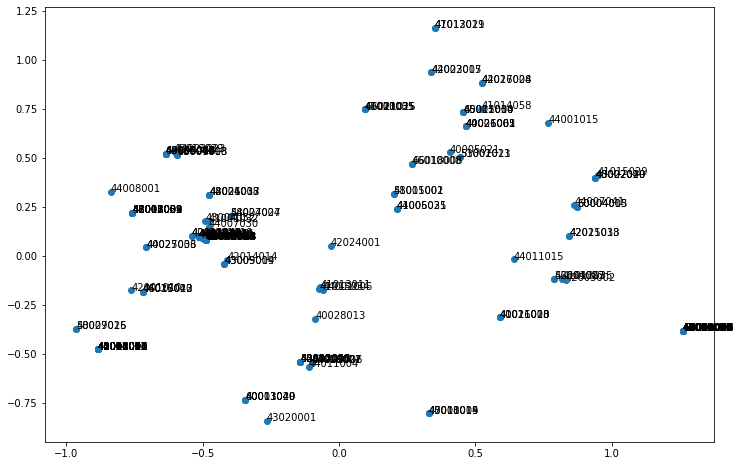

0 eng_at


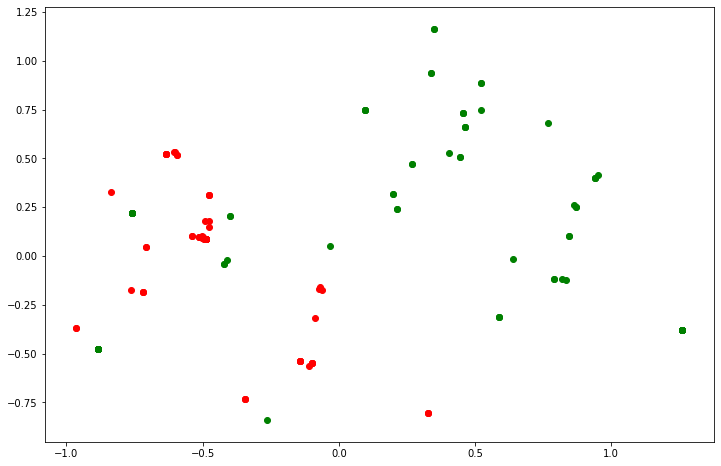

1 eng_in


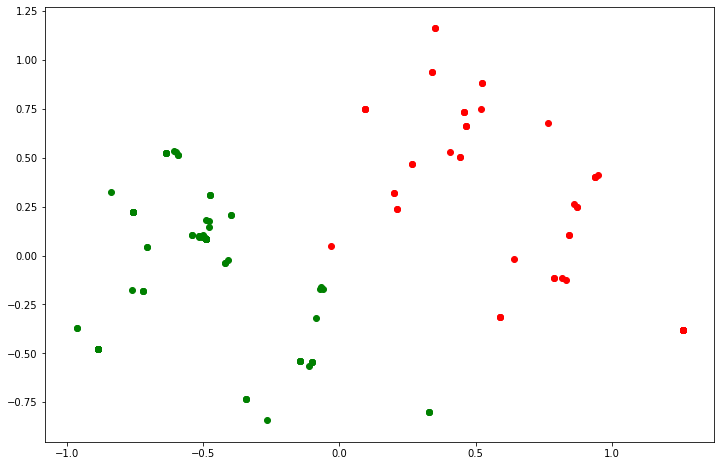

2 eng_on


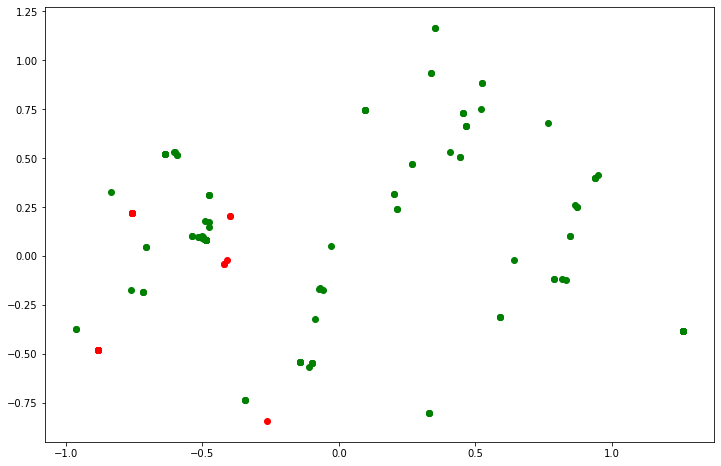

3 cym_yn


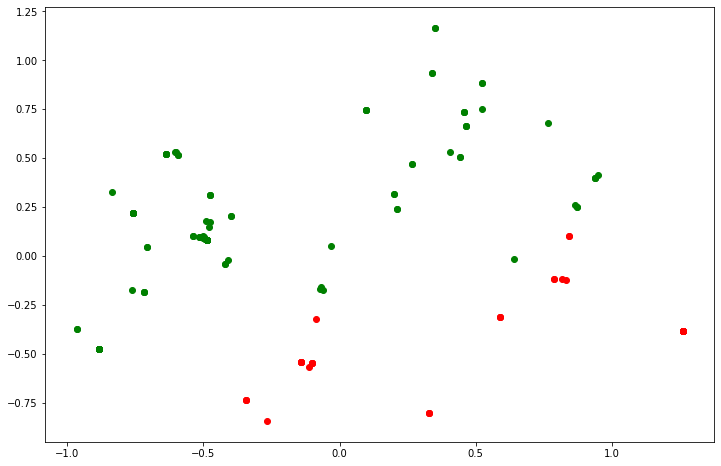

4 cym_wrth


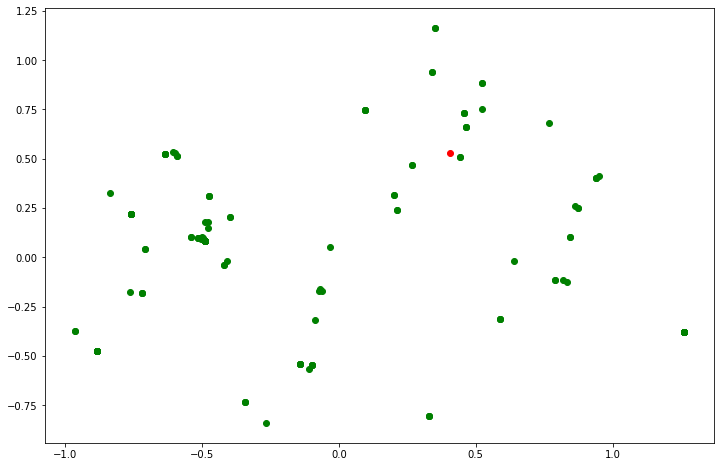

5 cym_o


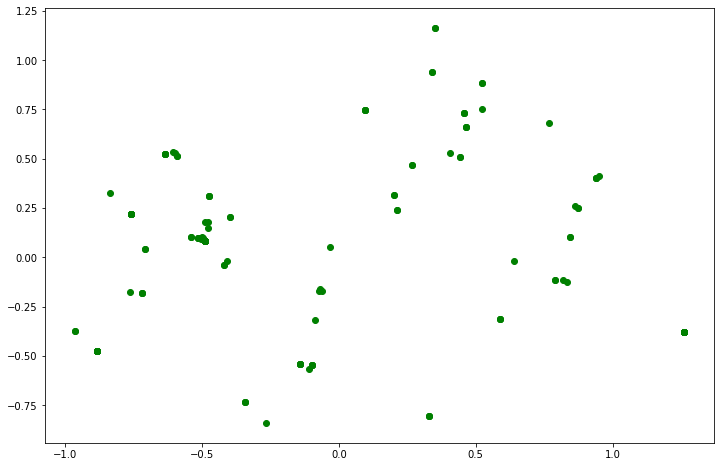

6 cym_ar


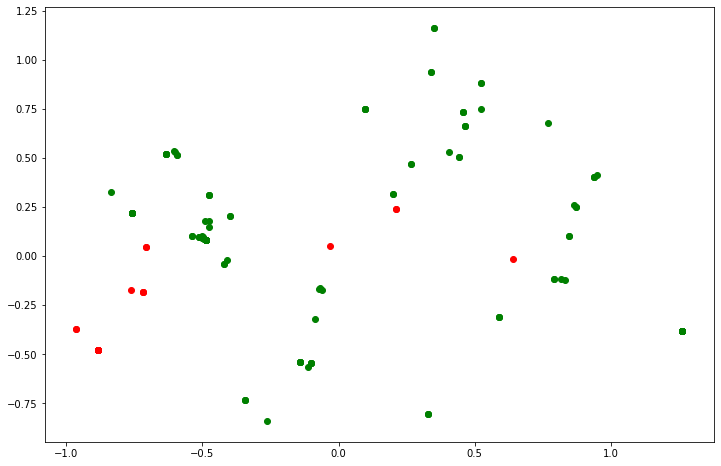

7 cym_zero


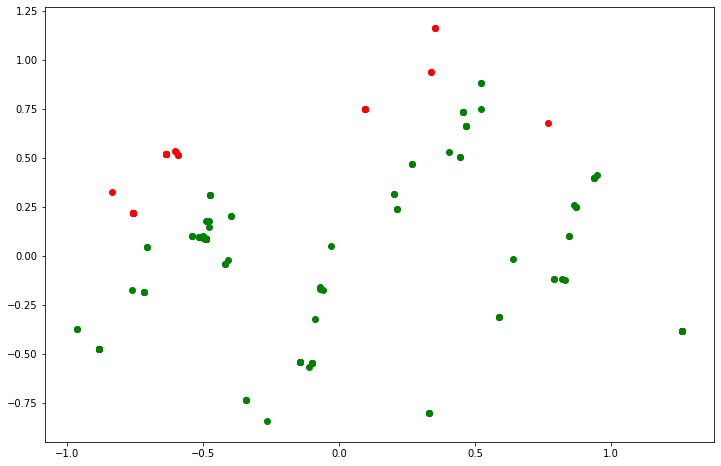

8 cym_pryd


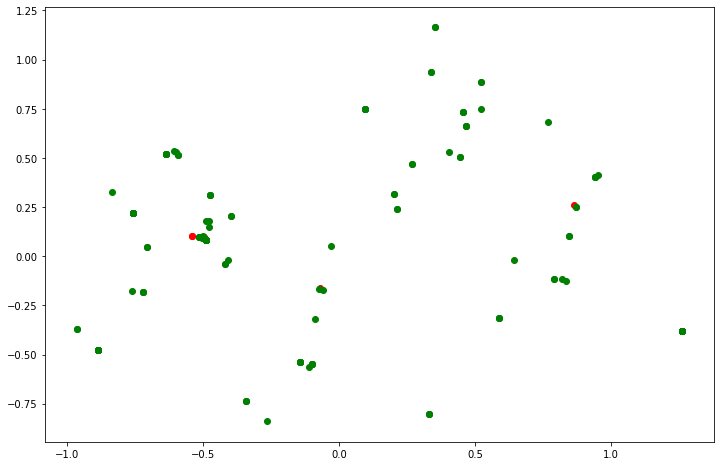

9 cym_ymhen


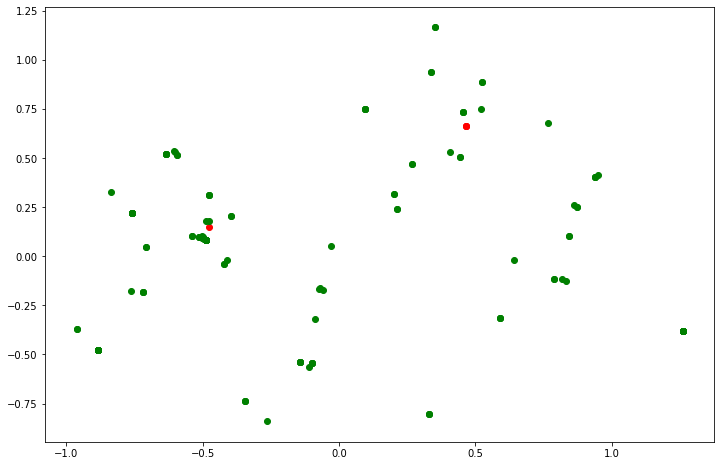

10 cym_mewn


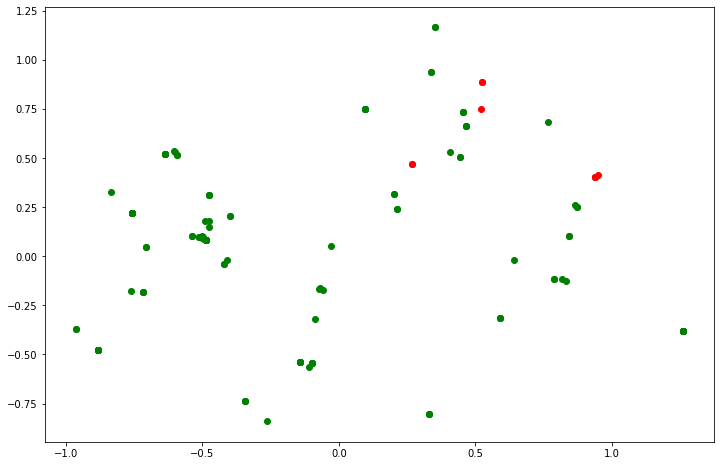

11 cym_tridiau


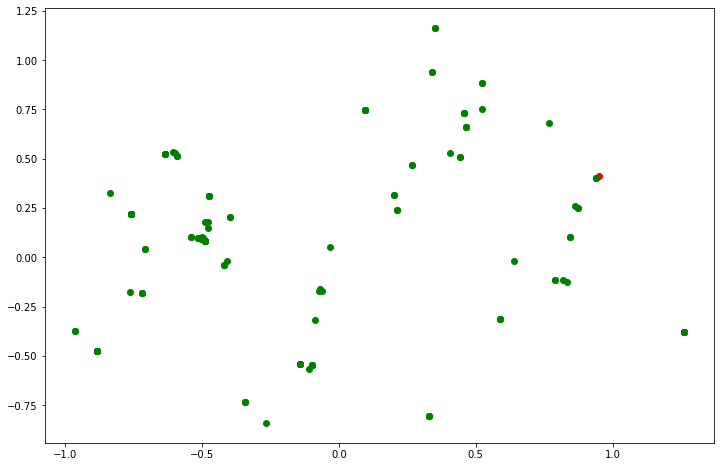

12 cym_am


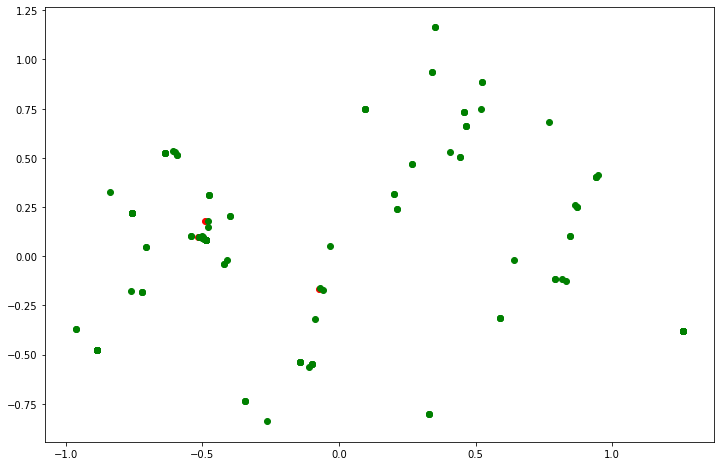

13 cym_tua


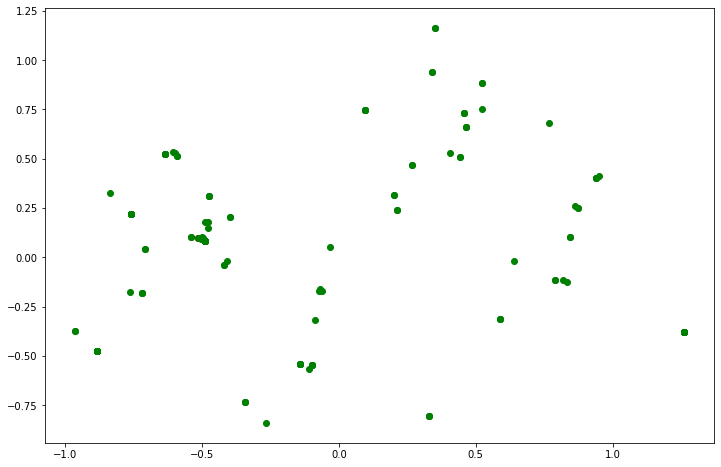

14 deu_zu


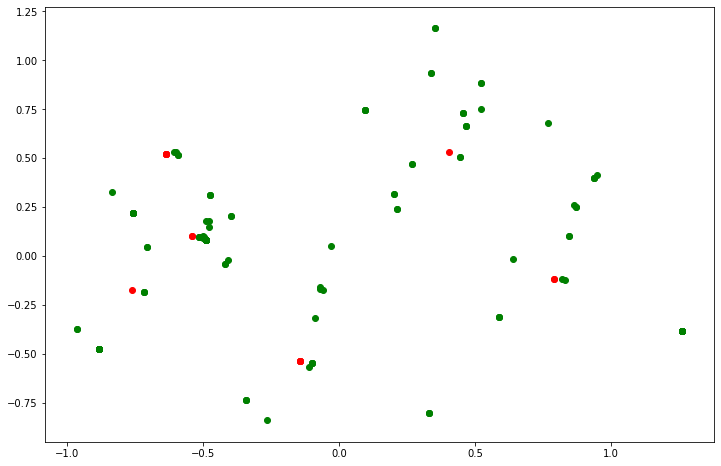

15 deu_in


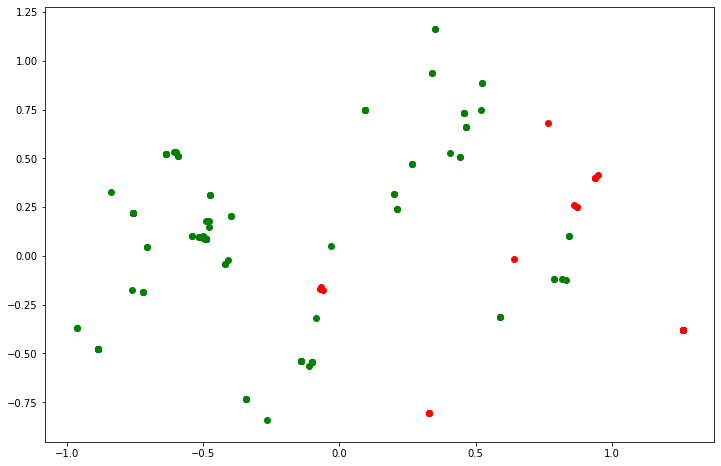

16 deu_an


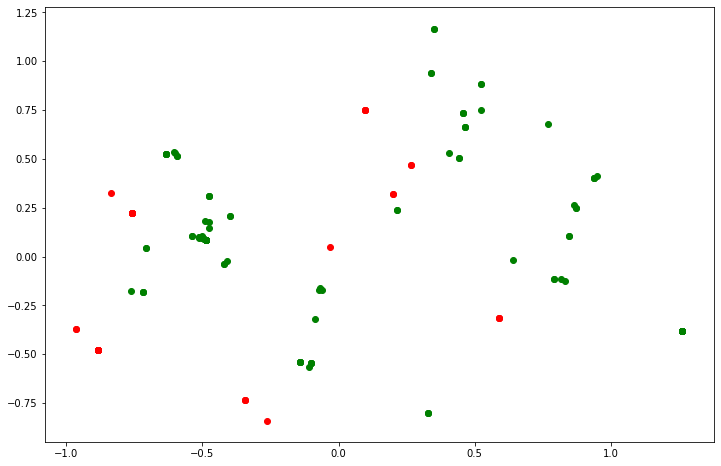

17 deu_zero


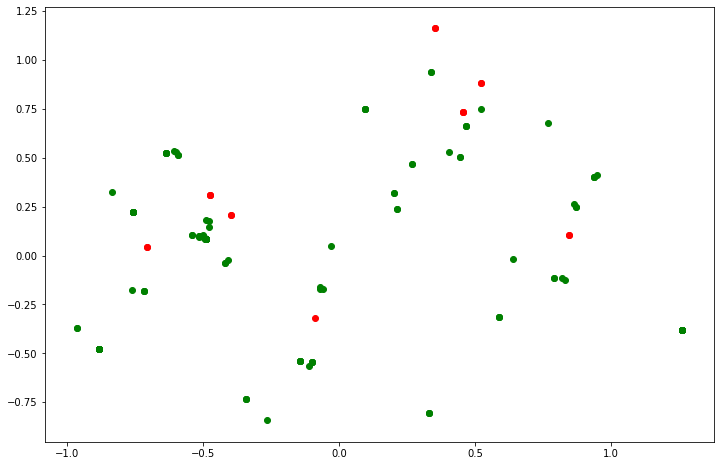

18 deu_nach


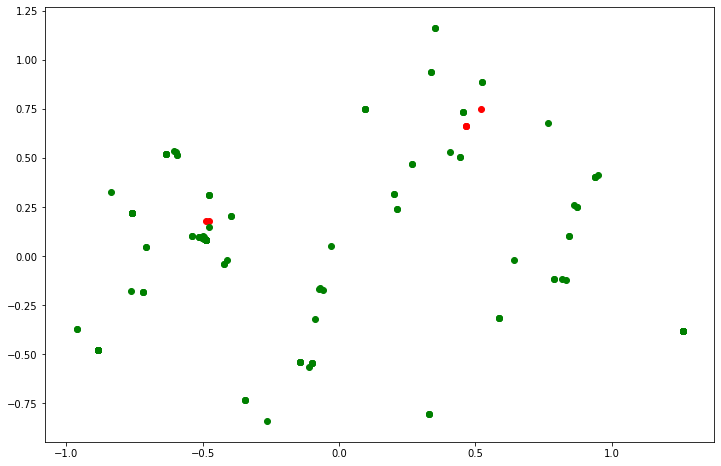

19 deu_um


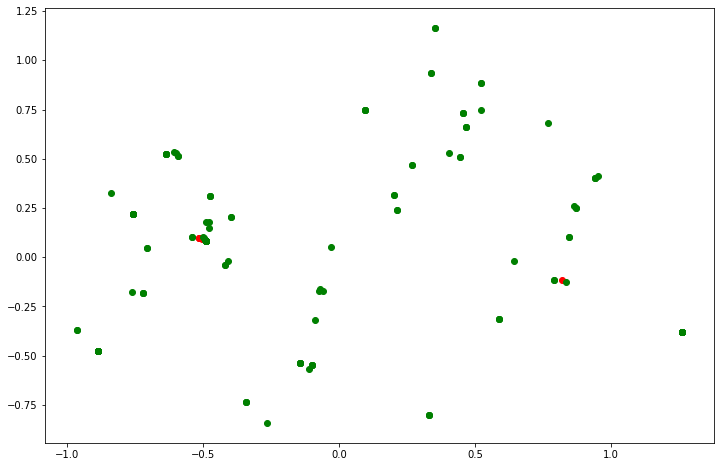

20 deu__an


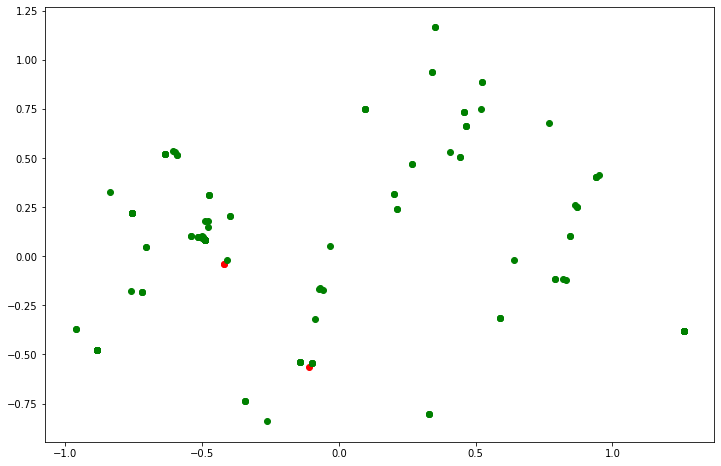

21 deu_bei


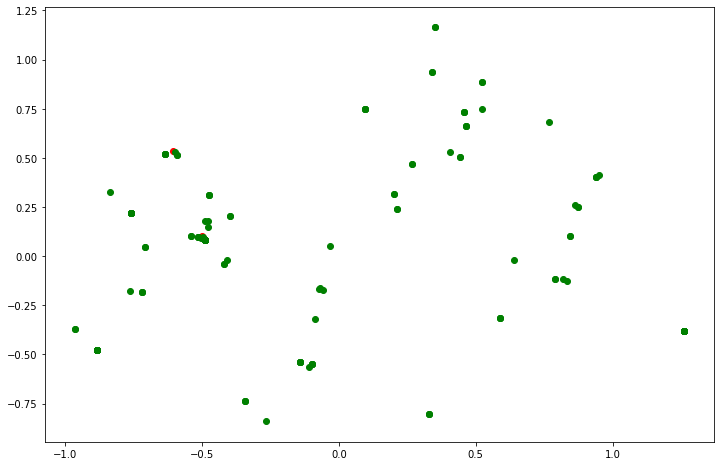

22 deu_von


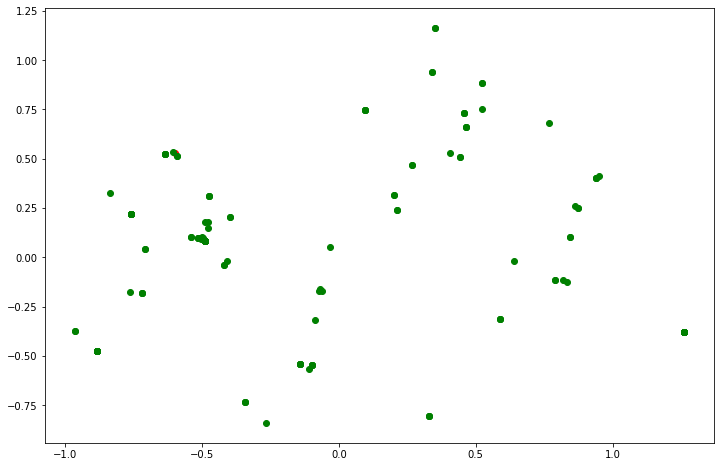

23 deu__nach


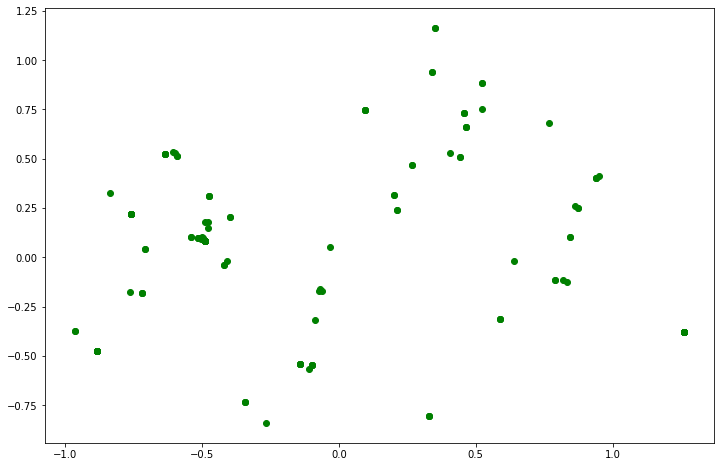

In [11]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (12,8)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    #plt.scatter(x=coordinates[no_translation,dimension_x]), y=coordinates[no_translation,dimension_y], c = 'gray')
    plt.show()
    plt.close()